# Electricity Demand Forecasting Dataset

## Data Sources

The dataset is collected from multiple reliable sources:

-  **Power Grid Company of Bangladesh (PGCB)**  
  Provides:
  - Electricity generation data  
  - Demand information  
  - Load shedding records  
  - Fuel mix (gas, coal, imports, etc.)

-  **Weather Data Sources**  
  Provides:
  - Temperature  
  - Humidity  
  - Rainfall  
  - Wind speed  

---

##  Data Integration

All datasets are merged using the `datetime column`.

This allows us to:
- Align power and weather data accurately  
- Perform time-based analysis  
- Understand real-world patterns in electricity usage  

---

##  Objectives

### 1.  Forecast Electricity Demand
- Predict future `demand_mw` values  
- Help in planning electricity supply  

### 2.  Estimate Actual Demand
- Include `load shedding` to estimate real demand  
- Understand hidden or unmet demand  

### 3.  Analyze Key Impacts


---

##  Purpose

- Support **energy planning**  
- Improve **grid stability**  
- Enable **data-driven decision making** in the power sector


In [216]:
# import dependencies
import pandas as pd
import numpy as np

# Dataset Loading

In [217]:
# dataset load
df = pd.read_csv("electricity_demand_weather_merged.csv")

In [218]:
df.head()

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks,temperature,humidity,rain,windspeed
0,2020-01-01 00:00:00,5913.0,5913,0,5493,0,160,47,0.0,NaN,129,76,NaN,NaN,NaN,18.3,74.0,0.0,3.5
1,2020-01-01 01:00:00,5570.0,5570,0,5117,0,160,47,0.0,NaN,129,74,NaN,NaN,NaN,16.5,81.0,0.0,6.0
2,2020-01-01 02:00:00,5351.0,5351,0,4900,0,159,47,0.0,NaN,129,72,NaN,NaN,NaN,14.6,89.0,0.0,8.4
3,2020-01-01 03:00:00,5223.0,5223,0,4773,0,160,46,0.0,NaN,129,70,NaN,NaN,NaN,14.5,90.0,0.0,6.3
4,2020-01-01 04:00:00,5142.0,5142,0,4697,0,159,46,0.0,NaN,129,68,NaN,NaN,NaN,14.1,90.0,0.0,8.2


In [219]:
df.tail()

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks,temperature,humidity,rain,windspeed
49847,2025-06-16 20:00:00,15000.0,15035,33,6361,1985,4168,172,0.0,64.0,924,26,1262.0,38.0,NaN,27.6,89.0,0.0,14.3
49848,2025-06-16 21:00:00,14971.0,15000,28,6373,1961,4134,172,0.0,59.0,924,40,1270.0,38.0,NaN,27.2,89.0,0.0,15.2
49849,2025-06-16 22:00:00,15109.0,15130,20,6421,1955,4228,172,0.0,45.0,924,36,1290.0,38.0,NaN,27.0,90.0,0.0,14.2
49850,2025-06-16 23:00:00,15165.0,15205,38,6437,1984,4268,172,0.0,41.0,924,42,1259.0,38.0,NaN,26.8,91.0,0.0,13.7
49851,2025-06-17 00:00:00,14628.0,14650,21,6302,1672,4186,172,0.0,41.0,924,42,1251.0,38.0,NaN,26.7,91.0,0.1,14.3


In [220]:
df.columns

Index(['datetime', 'generation_mw', 'demand_mw', 'load_shedding', 'gas',
       'liquid_fuel', 'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc',
       'india_tripura', 'india_adani', 'nepal', 'remarks', 'temperature',
       'humidity', 'rain', 'windspeed'],
      dtype='object')

In [221]:
df.dtypes

datetime                 object
generation_mw           float64
demand_mw                 int64
load_shedding             int64
gas                       int64
liquid_fuel               int64
coal                      int64
hydro                     int64
solar                   float64
wind                    float64
india_bheramara_hvdc      int64
india_tripura             int64
india_adani             float64
nepal                   float64
remarks                  object
temperature             float64
humidity                float64
rain                    float64
windspeed               float64
dtype: object

In [222]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49852 entries, 0 to 49851
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   datetime              49852 non-null  object 
 1   generation_mw         49852 non-null  float64
 2   demand_mw             49852 non-null  int64  
 3   load_shedding         49852 non-null  int64  
 4   gas                   49852 non-null  int64  
 5   liquid_fuel           49852 non-null  int64  
 6   coal                  49852 non-null  int64  
 7   hydro                 49852 non-null  int64  
 8   solar                 49852 non-null  float64
 9   wind                  18664 non-null  float64
 10  india_bheramara_hvdc  49852 non-null  int64  
 11  india_tripura         49852 non-null  int64  
 12  india_adani           7326 non-null   float64
 13  nepal                 5339 non-null   float64
 14  remarks               3794 non-null   object 
 15  temperature        

In [223]:
df.shape

(49852, 19)

# Data Description Table

| Column Name              | Data Type | Description |
|-------------------------|----------|-------------|
| datetime                | object   | Timestamp (needs conversion to datetime) |
| generation_mw           | float64  | Total electricity generation |
| demand_mw               | int64    | supplied (served demand) |
| load_shedding           | int64    | Unserved demand (power shortage) |
| gas                     | int64    | Gas-based generation |
| liquid_fuel             | int64    | Furnace oil / diesel generation |
| coal                    | int64    | Coal-based generation |
| hydro                   | int64    | Hydropower generation |
| solar                   | float64  | Solar generation |
| wind                    | float64  | Wind generation (many missing values) |
| india_bheramara_hvdc    | int64    | Power import via HVDC |
| india_tripura           | int64    | Import from Tripura |
| india_adani             | float64  | Import from Adani (sparse) |
| nepal                   | float64  | Import from Nepal (sparse) |
| remarks                 | object   | Special notes/events |
| temperature             | float64  | Temperature (°C) |
| humidity                | float64  | Humidity (%) |
| rain                    | float64  | Rainfall (mm) |
| windspeed               | float64  | Wind speed |

# Data Preprocessing

In [224]:
# Rename Columns for Consistency
df = df.rename(columns={
    'generation_mw': 'gen_total_mw',
    'load_shedding': 'load_shedding_mw',
    'gas': 'gen_gas_mw',
    'liquid_fuel': 'gen_liquid_fuel_mw',
    'coal': 'gen_coal_mw',
    'hydro': 'gen_hydro_mw',
    'solar': 'gen_solar_mw',
    'wind': 'gen_wind_mw',
    'india_bheramara_hvdc': 'import_india_bheramara_mw',
    'india_tripura': 'import_india_tripura_mw',
    'india_adani': 'import_india_adani_mw',
    'nepal': 'import_nepal_mw',
    'temperature': 'temp_c',
    'humidity': 'humidity_pct',
    'rain': 'rain_mm',
    'windspeed': 'wind_speed_ms'
})

In [225]:
df.head()

,datetime,gen_total_mw,demand_mw,load_shedding_mw,gen_gas_mw,gen_liquid_fuel_mw,gen_coal_mw,gen_hydro_mw,gen_solar_mw,gen_wind_mw,import_india_bheramara_mw,import_india_tripura_mw,import_india_adani_mw,import_nepal_mw,remarks,temp_c,humidity_pct,rain_mm,wind_speed_ms
0,2020-01-01 00:00:00,5913.0,5913,0,5493,0,160,47,0.0,NaN,129,76,NaN,NaN,NaN,18.3,74.0,0.0,3.5
1,2020-01-01 01:00:00,5570.0,5570,0,5117,0,160,47,0.0,NaN,129,74,NaN,NaN,NaN,16.5,81.0,0.0,6.0
2,2020-01-01 02:00:00,5351.0,5351,0,4900,0,159,47,0.0,NaN,129,72,NaN,NaN,NaN,14.6,89.0,0.0,8.4
3,2020-01-01 03:00:00,5223.0,5223,0,4773,0,160,46,0.0,NaN,129,70,NaN,NaN,NaN,14.5,90.0,0.0,6.3
4,2020-01-01 04:00:00,5142.0,5142,0,4697,0,159,46,0.0,NaN,129,68,NaN,NaN,NaN,14.1,90.0,0.0,8.2


In [226]:
# check null value 
df['datetime'].isna().sum()

np.int64(0)

In [227]:
# Convert datetime column
df['datetime'] = pd.to_datetime(df['datetime'])

In [228]:
# Sort values 
df = df.sort_values('datetime')

In [229]:
# Set index
df = df.set_index('datetime')

In [230]:
df.head()

,gen_total_mw,demand_mw,load_shedding_mw,gen_gas_mw,gen_liquid_fuel_mw,gen_coal_mw,gen_hydro_mw,gen_solar_mw,gen_wind_mw,import_india_bheramara_mw,import_india_tripura_mw,import_india_adani_mw,import_nepal_mw,remarks,temp_c,humidity_pct,rain_mm,wind_speed_ms
datetime,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,5913.0,5913,0,5493,0,160,47,0.0,NaN,129,76,NaN,NaN,NaN,18.3,74.0,0.0,3.5
2020-01-01 01:00:00,5570.0,5570,0,5117,0,160,47,0.0,NaN,129,74,NaN,NaN,NaN,16.5,81.0,0.0,6.0
2020-01-01 02:00:00,5351.0,5351,0,4900,0,159,47,0.0,NaN,129,72,NaN,NaN,NaN,14.6,89.0,0.0,8.4
2020-01-01 03:00:00,5223.0,5223,0,4773,0,160,46,0.0,NaN,129,70,NaN,NaN,NaN,14.5,90.0,0.0,6.3
2020-01-01 04:00:00,5142.0,5142,0,4697,0,159,46,0.0,NaN,129,68,NaN,NaN,NaN,14.1,90.0,0.0,8.2


In [231]:
# check missing values
df.isnull().sum()

gen_total_mw                     0
demand_mw                        0
load_shedding_mw                 0
gen_gas_mw                       0
gen_liquid_fuel_mw               0
gen_coal_mw                      0
gen_hydro_mw                     0
gen_solar_mw                     0
gen_wind_mw                  31188
import_india_bheramara_mw        0
import_india_tripura_mw          0
import_india_adani_mw        42526
import_nepal_mw              44513
remarks                      46058
temp_c                        1991
humidity_pct                  1991
rain_mm                       1991
wind_speed_ms                 1991
dtype: int64

In [232]:
# missing values percentage
np.round(df.isna().mean()*100, 2)

gen_total_mw                  0.00
demand_mw                     0.00
load_shedding_mw              0.00
gen_gas_mw                    0.00
gen_liquid_fuel_mw            0.00
gen_coal_mw                   0.00
gen_hydro_mw                  0.00
gen_solar_mw                  0.00
gen_wind_mw                  62.56
import_india_bheramara_mw     0.00
import_india_tripura_mw       0.00
import_india_adani_mw        85.30
import_nepal_mw              89.29
remarks                      92.39
temp_c                        3.99
humidity_pct                  3.99
rain_mm                       3.99
wind_speed_ms                 3.99
dtype: float64

## Null Values in the Dataset

After checking the dataset, I found that **most columns have 0% null values**.

However, the following columns contain **constant non-zero values**, which might indicate placeholder or default data instead of actual collected values:
- `gen_wind_mw` - 62.56% of values are identical
- `import_india_adani_mw` - 85.30% of values are identical
- `import_nepal_mw` - 89.29% of values are identical
- `remarks` – 92.39% of values are identical
- `temp_c` – 3.99% of values are identical
- `humidity_pct` – 3.99% of values are identical
- `rain_mm` – 3.99% of values are identical
- `wind_speed_ms` – 3.99% of values are identical

In [233]:
# Check time range
print("Start:", df.index.min())
print("End:", df.index.max())

Start: 2020-01-01 00:00:00
End: 2025-06-17 00:00:00


## Handling Missing values

### **`gen_wind_mw`,`import_india_adani_mw`, and `import_nepal_mw` columns**
- The missing values in `gen_wind_mw`, `import_india_adani_mw`, and `import_nepal_mw` represent structural zeros rather than true missing data. These sources are inactive for large periods, so missing entries indicate no generation or import. Therefore, filling with zero preserves the real-world meaning of the data and avoids introducing artificial patterns into the model.

In [234]:
# fill missing values
df['gen_wind_mw'].fillna(0, inplace=True)
df['import_india_adani_mw'].fillna(0, inplace=True)
df['import_nepal_mw'].fillna(0, inplace=True)

C:\Users\dclid\AppData\Local\Temp\ipykernel_11304\811341114.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['gen_wind_mw'].fillna(0, inplace=True)
C:\Users\dclid\AppData\Local\Temp\ipykernel_11304\811341114.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, whe

### **`remarks` Column**

In [235]:
# find unique remaks value
df['remarks'].unique()

array([nan, 'Day_Peak', 'Evening_Peak'], dtype=object)

In [236]:
# create a new columns of hours (feature engineering)
df['hour'] = df.index.hour

In [237]:
# find unique 'hours'
df['hour'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 23, 22], dtype=int32)

In [238]:
# check electicity demand for different hours
df.groupby(df.index.hour)['demand_mw'].mean()

datetime
0     10272.610025
1      9900.017060
2      9660.555165
3      9488.279980
4      9187.461423
5      8941.368104
6      8973.097438
7      9262.379569
8      9471.846308
9      9645.950401
10     9867.537381
11    10232.788867
12    10482.272682
13    10321.533133
14    10334.871178
15    10128.062720
16     9992.128822
17    10394.373747
18    11581.148808
19    11631.910866
20    11593.029087
21    11334.526817
22    11036.527081
23    10724.221665
Name: demand_mw, dtype: float64

### Decision Making
---
**Evening Peak (clearly highest)**
- Hour 18 → 11581
- Hour 19 → 11631 (peak)
- Hour 20 → 11593

18-20 is Evening_Peak

---
**Day Peak (moderate-high)**
- Hour 9–17 range is ~10,000–10,400

9–17 is Day_Peak

---
**Night Peak & Late_Evening**
- Hour 0–6 lowest values (~8900–9900)
0–6 is Night_Peak & 21–23 is Late_Evening
---

In [239]:
df['remarks'] = np.select(
    [
        df['hour'].between(18, 20),
        df['hour'].between(9, 17),
        df['hour'].between(0, 6),
        df['hour'].between(21, 23)
    ],
    [
        'Evening_Peak',
        'Day_Peak',
        'Night_OffPeak',
        'Late_Evening'
    ],
    default='Day_Peak'
)

In [240]:
df.isna().sum()

gen_total_mw                    0
demand_mw                       0
load_shedding_mw                0
gen_gas_mw                      0
gen_liquid_fuel_mw              0
gen_coal_mw                     0
gen_hydro_mw                    0
gen_solar_mw                    0
gen_wind_mw                     0
import_india_bheramara_mw       0
import_india_tripura_mw         0
import_india_adani_mw           0
import_nepal_mw                 0
remarks                         0
temp_c                       1991
humidity_pct                 1991
rain_mm                      1991
wind_speed_ms                1991
hour                            0
dtype: int64

### **`Weather` Data handling**

In [241]:
# check index values of null values in 'temp_c' column
temp_c_null_index = df[df['temp_c'].isna()].index
temp_c_null_index

DatetimeIndex(['2020-01-01 18:30:00', '2020-01-02 18:30:00',
               '2020-01-03 18:30:00', '2020-01-04 18:30:00',
               '2020-01-05 18:30:00', '2020-01-06 18:30:00',
               '2020-01-07 18:30:00', '2020-01-08 18:30:00',
               '2020-01-09 18:30:00', '2020-01-10 18:30:00',
               ...
               '2025-06-07 18:30:00', '2025-06-08 18:30:00',
               '2025-06-09 18:30:00', '2025-06-10 18:30:00',
               '2025-06-11 18:30:00', '2025-06-12 18:30:00',
               '2025-06-13 18:30:00', '2025-06-14 18:30:00',
               '2025-06-15 18:30:00', '2025-06-16 18:30:00'],
              dtype='datetime64[ns]', name='datetime', length=1991, freq=None)

In [242]:
# check index values of null values in 'humidity_pct' column
humidity_pct_null_index = df[df['humidity_pct'].isna()].index
humidity_pct_null_index

DatetimeIndex(['2020-01-01 18:30:00', '2020-01-02 18:30:00',
               '2020-01-03 18:30:00', '2020-01-04 18:30:00',
               '2020-01-05 18:30:00', '2020-01-06 18:30:00',
               '2020-01-07 18:30:00', '2020-01-08 18:30:00',
               '2020-01-09 18:30:00', '2020-01-10 18:30:00',
               ...
               '2025-06-07 18:30:00', '2025-06-08 18:30:00',
               '2025-06-09 18:30:00', '2025-06-10 18:30:00',
               '2025-06-11 18:30:00', '2025-06-12 18:30:00',
               '2025-06-13 18:30:00', '2025-06-14 18:30:00',
               '2025-06-15 18:30:00', '2025-06-16 18:30:00'],
              dtype='datetime64[ns]', name='datetime', length=1991, freq=None)

In [243]:
# check index values of null values in 'rain_mm' column
rain_mm_null_index = df[df['rain_mm'].isna()].index
rain_mm_null_index

DatetimeIndex(['2020-01-01 18:30:00', '2020-01-02 18:30:00',
               '2020-01-03 18:30:00', '2020-01-04 18:30:00',
               '2020-01-05 18:30:00', '2020-01-06 18:30:00',
               '2020-01-07 18:30:00', '2020-01-08 18:30:00',
               '2020-01-09 18:30:00', '2020-01-10 18:30:00',
               ...
               '2025-06-07 18:30:00', '2025-06-08 18:30:00',
               '2025-06-09 18:30:00', '2025-06-10 18:30:00',
               '2025-06-11 18:30:00', '2025-06-12 18:30:00',
               '2025-06-13 18:30:00', '2025-06-14 18:30:00',
               '2025-06-15 18:30:00', '2025-06-16 18:30:00'],
              dtype='datetime64[ns]', name='datetime', length=1991, freq=None)

In [244]:
# check index values of null values in 'wind_speed_ms' column
wind_speed_null_index = df[df['wind_speed_ms'].isna()].index
wind_speed_null_index

DatetimeIndex(['2020-01-01 18:30:00', '2020-01-02 18:30:00',
               '2020-01-03 18:30:00', '2020-01-04 18:30:00',
               '2020-01-05 18:30:00', '2020-01-06 18:30:00',
               '2020-01-07 18:30:00', '2020-01-08 18:30:00',
               '2020-01-09 18:30:00', '2020-01-10 18:30:00',
               ...
               '2025-06-07 18:30:00', '2025-06-08 18:30:00',
               '2025-06-09 18:30:00', '2025-06-10 18:30:00',
               '2025-06-11 18:30:00', '2025-06-12 18:30:00',
               '2025-06-13 18:30:00', '2025-06-14 18:30:00',
               '2025-06-15 18:30:00', '2025-06-16 18:30:00'],
              dtype='datetime64[ns]', name='datetime', length=1991, freq=None)

In [245]:
temp_c_null_index.equals(humidity_pct_null_index) and \
humidity_pct_null_index.equals(rain_mm_null_index) and \
rain_mm_null_index.equals(wind_speed_null_index)

True

**Missing values are not random They are systematically tied to 30-minute timestamps**

In [246]:
df.head()

,gen_total_mw,demand_mw,load_shedding_mw,gen_gas_mw,gen_liquid_fuel_mw,gen_coal_mw,gen_hydro_mw,gen_solar_mw,gen_wind_mw,import_india_bheramara_mw,import_india_tripura_mw,import_india_adani_mw,import_nepal_mw,remarks,temp_c,humidity_pct,rain_mm,wind_speed_ms,hour
datetime,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,5913.0,5913,0,5493,0,160,47,0.0,0.0,129,76,0.0,0.0,Night_OffPeak,18.3,74.0,0.0,3.5,0
2020-01-01 01:00:00,5570.0,5570,0,5117,0,160,47,0.0,0.0,129,74,0.0,0.0,Night_OffPeak,16.5,81.0,0.0,6.0,1
2020-01-01 02:00:00,5351.0,5351,0,4900,0,159,47,0.0,0.0,129,72,0.0,0.0,Night_OffPeak,14.6,89.0,0.0,8.4,2
2020-01-01 03:00:00,5223.0,5223,0,4773,0,160,46,0.0,0.0,129,70,0.0,0.0,Night_OffPeak,14.5,90.0,0.0,6.3,3
2020-01-01 04:00:00,5142.0,5142,0,4697,0,159,46,0.0,0.0,129,68,0.0,0.0,Night_OffPeak,14.1,90.0,0.0,8.2,4


In [247]:
# total indexs in half-hour
df.index.minute.value_counts()

datetime
0     47861
30     1991
Name: count, dtype: int64

In [248]:
df.index.to_series().diff().value_counts().head()

datetime
0 days 01:00:00    45709
0 days 00:30:00     3978
0 days 00:00:00       86
0 days 02:00:00       73
0 days 03:00:00        3
Name: count, dtype: int64

## *Problem Overview*
During exploratory analysis, observed that the dataset contains mixed timestamp frequencies, like
- Majority of timestamps are hourly.
- A smaller portion (~1991 rows) are half-hourly.
---
### Missing Values Pattern
Also found that all missing values in weather-related columns, `temp_c`, `humidity_pct`, `rain_mm`, `wind_speed_ms` occur exactly in the half-hourly (30-minute) rows.

### Key Insight
This indicates a data integration issue, where:

- Electricity data is recorded hourly
- Some intermediate 30-minute timestamps were introduced
- Weather data is not available for these timestamps

**Final Decision:**  Keep Only Hourly Data, Remove all half-hour (minute = 30) rows

In [249]:
# Keep only hourly timestamps
df = df[df.index.minute == 0]

In [250]:
df.isna().sum()

gen_total_mw                 0
demand_mw                    0
load_shedding_mw             0
gen_gas_mw                   0
gen_liquid_fuel_mw           0
gen_coal_mw                  0
gen_hydro_mw                 0
gen_solar_mw                 0
gen_wind_mw                  0
import_india_bheramara_mw    0
import_india_tripura_mw      0
import_india_adani_mw        0
import_nepal_mw              0
remarks                      0
temp_c                       0
humidity_pct                 0
rain_mm                      0
wind_speed_ms                0
hour                         0
dtype: int64

In [251]:
# check duplicate values
df.duplicated().sum()

np.int64(13)

In [252]:
# Inspect duplicates
df[df.duplicated()]

,gen_total_mw,demand_mw,load_shedding_mw,gen_gas_mw,gen_liquid_fuel_mw,gen_coal_mw,gen_hydro_mw,gen_solar_mw,gen_wind_mw,import_india_bheramara_mw,import_india_tripura_mw,import_india_adani_mw,import_nepal_mw,remarks,temp_c,humidity_pct,rain_mm,wind_speed_ms,hour
datetime,,,,,,,,,,,,,,,,,,,
2022-01-05 15:00:00,7280.0,7280,0,3786,2100,499,86,42.0,0.0,684,95,0.0,0.0,Day_Peak,23.8,58.0,0.0,6.2,15
2022-02-01 17:00:00,9170.0,9170,0,3746,4033,520,46,0.0,0.0,743,104,0.0,0.0,Day_Peak,21.5,74.0,0.0,10.6,17
2022-02-13 13:00:00,8394.0,8394,0,3848,2958,540,46,191.0,0.0,752,74,0.0,0.0,Day_Peak,24.0,48.0,0.0,10.8,13
2022-02-16 19:00:00,9608.0,9608,0,4396,3686,650,46,0.0,0.0,738,108,0.0,0.0,Evening_Peak,18.5,53.0,0.0,9.0,19
2022-02-18 21:00:00,8173.0,8173,0,4440,2259,600,74,0.0,0.0,734,80,0.0,0.0,Late_Evening,16.0,74.0,0.0,9.3,21
2022-03-20 12:00:00,11552.0,11552,0,5474,4092,889,35,204.0,0.0,731,142,0.0,0.0,Day_Peak,33.0,36.0,0.0,8.3,12
2022-05-12 20:00:00,12736.0,12736,0,5771,4933,1135,30,0.0,0.0,915,108,0.0,0.0,Evening_Peak,26.9,89.0,0.0,13.2,20
2022-05-31 04:00:00,11229.0,11229,0,6166,2957,1016,65,0.0,0.0,938,102,0.0,0.0,Night_OffPeak,25.8,95.0,0.0,7.0,4
2022-06-03 16:00:00,9704.0,9704,0,5473,2290,855,65,21.0,0.0,922,94,0.0,0.0,Day_Peak,30.0,78.0,0.2,14.8,16


In [253]:
# find index duplicated value
df.index.duplicated().sum()

np.int64(85)

In [254]:
df[df.index.duplicated(keep=False)].sample(10)

,gen_total_mw,demand_mw,load_shedding_mw,gen_gas_mw,gen_liquid_fuel_mw,gen_coal_mw,gen_hydro_mw,gen_solar_mw,gen_wind_mw,import_india_bheramara_mw,import_india_tripura_mw,import_india_adani_mw,import_nepal_mw,remarks,temp_c,humidity_pct,rain_mm,wind_speed_ms,hour
datetime,,,,,,,,,,,,,,,,,,,
2022-04-07 21:00:00,14008.0,14008,0,5631,6192,954,103,0.0,0.0,935,162,0.0,0.0,Late_Evening,30.1,65.0,0.0,1.0,21
2020-02-09 07:00:00,7359.7,7360,0,5692,483,530,68,9.7,0.0,501,82,0.0,0.0,Day_Peak,15.6,87.0,0.0,5.8,7
2023-02-28 23:00:00,9745.0,9745,0,5343,1918,1471,30,0.0,0.0,906,102,0.0,0.0,Late_Evening,20.8,52.0,0.0,8.5,23
2021-05-24 23:00:00,13315.0,13315,0,6645,4846,720,25,0.0,0.0,928,166,0.0,0.0,Late_Evening,30.2,78.0,0.0,5.9,23
2020-04-29 23:00:00,6209.0,6209,0,4894,0,450,38,0.0,0.0,743,94,0.0,0.0,Late_Evening,24.1,94.0,0.0,5.4,23
2022-01-14 13:00:00,6748.0,6748,0,3137,2373,499,75,63.0,0.0,532,79,0.0,0.0,Day_Peak,22.1,44.0,0.0,8.6,13
2020-01-02 22:00:00,6777.0,6777,0,5998,162,175,46,0.0,0.0,313,84,0.0,0.0,Late_Evening,19.0,92.0,0.0,5.8,22
2024-03-25 09:00:00,10323.0,10323,0,5288,308,3458,30,336.0,0.0,781,122,0.0,0.0,Day_Peak,26.5,82.0,0.0,10.2,9
2023-02-22 23:00:00,9208.0,9230,20,4883,1660,1622,30,0.0,0.0,916,114,0.0,0.0,Late_Evening,23.1,80.0,0.0,15.0,23


In [255]:
# remove duplicate rows
df = df.drop_duplicates()

In [256]:
df.index.duplicated().sum()

np.int64(72)

#### Apply Aggregation strategy.
Aggregation strategy means, decision rules to merge duplicate timestamps.
Deciding that:

- combine numbers → mean
- combine categories → first/mode

In [257]:
numeric_cols = df.select_dtypes(include=['number']).columns
object_cols = df.select_dtypes(include=['object']).columns

In [258]:
df = df.groupby(df.index).agg({
    **{col: 'mean' for col in numeric_cols},
    **{col: lambda x: x.mode()[0] if not x.mode().empty else None for col in object_cols}
})

In [259]:
# recheck null values
df.isna().sum()

gen_total_mw                 0
demand_mw                    0
load_shedding_mw             0
gen_gas_mw                   0
gen_liquid_fuel_mw           0
gen_coal_mw                  0
gen_hydro_mw                 0
gen_solar_mw                 0
gen_wind_mw                  0
import_india_bheramara_mw    0
import_india_tripura_mw      0
import_india_adani_mw        0
import_nepal_mw              0
temp_c                       0
humidity_pct                 0
rain_mm                      0
wind_speed_ms                0
hour                         0
remarks                      0
dtype: int64

In [260]:
# recheck duplicates value
df.duplicated().sum()

np.int64(0)

In [261]:
# recheck index duplicates
df.index.duplicated().sum()

np.int64(0)

In [262]:
df.shape

(47776, 19)

In [263]:
# statistical analysis
df.describe()

,gen_total_mw,demand_mw,load_shedding_mw,gen_gas_mw,gen_liquid_fuel_mw,gen_coal_mw,gen_hydro_mw,gen_solar_mw,gen_wind_mw,import_india_bheramara_mw,import_india_tripura_mw,import_india_adani_mw,import_nepal_mw,temp_c,humidity_pct,rain_mm,wind_speed_ms,hour
count,4.777600e+04,47776.000000,47776.000000,47776.000000,4.777600e+04,47776.000000,47776.000000,47776.000000,47776.000000,47776.000000,47776.000000,47776.000000,47776.000000,47776.000000,47776.000000,47776.000000,47776.000000,47776.000000
mean,1.137379e+04,10176.472811,147.796467,5376.684528,2.449005e+03,1660.240330,84.736709,66.446725,3.469305,789.851254,102.173895,128.924282,0.049313,25.612400,75.795776,0.200262,9.190422,11.490351
std,2.951741e+05,2562.575107,394.925814,1042.110199,1.336947e+05,1317.091934,68.325746,123.171663,11.016224,197.643249,39.298740,341.715034,1.368035,5.257086,16.934728,0.926939,4.945250,6.918274
min,5.710000e+02,143.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.600000,15.000000,0.000000,0.000000,0.000000
25%,8.324000e+03,8341.000000,0.000000,4711.000000,7.430000e+02,592.000000,40.000000,0.000000,0.000000,723.000000,78.000000,0.000000,0.000000,22.500000,66.000000,0.000000,5.900000,5.000000
50%,1.002600e+04,10086.000000,0.000000,5421.000000,1.627000e+03,1037.000000,70.000000,0.000000,0.000000,889.000000,102.000000,0.000000,0.000000,26.600000,80.000000,0.000000,8.000000,11.000000
75%,1.171700e+04,11950.000000,58.000000,6018.000000,2.720000e+03,2770.250000,123.000000,77.000000,0.000000,922.000000,128.000000,0.000000,0.000000,29.100000,90.000000,0.000000,11.600000,17.000000
max,6.452650e+07,121000.000000,13800.000000,66662.000000,2.922290e+07,31687.000000,4860.000000,2998.000000,922.000000,9410.000000,1565.000000,12665.000000,38.000000,40.800000,100.000000,39.500000,55.500000,23.000000


### Feature Engineering

In [264]:
df['month_name'] = df.index.month_name()
df['day_name'] = df.index.day_name()

In [265]:
df['day_name'].unique()

array(['Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday', 'Monday',
       'Tuesday'], dtype=object)

In [266]:
df[df['day_name'].isin(['Friday','Saturday'])].sample(5)

,gen_total_mw,demand_mw,load_shedding_mw,gen_gas_mw,gen_liquid_fuel_mw,gen_coal_mw,gen_hydro_mw,gen_solar_mw,gen_wind_mw,import_india_bheramara_mw,...,import_india_adani_mw,import_nepal_mw,temp_c,humidity_pct,rain_mm,wind_speed_ms,hour,remarks,month_name,day_name
datetime,,,,,,,,,,,,,,,,,,,,,
2024-11-09 09:00:00,9041.0,9041.0,0.0,4386.0,316.0,2154.0,133.0,589.0,0.0,896.0,...,517.0,0.0,26.1,65.0,0.0,11.8,9.0,Day_Peak,November,Saturday
2022-04-23 20:00:00,13766.0,13766.0,0.0,5583.0,6152.0,895.0,58.0,0.0,0.0,936.0,...,0.0,0.0,28.3,82.0,0.0,10.5,20.0,Evening_Peak,April,Saturday
2024-10-04 08:00:00,9526.0,9526.0,0.0,4496.0,307.0,2616.0,170.0,148.0,23.0,894.0,...,832.0,0.0,26.9,91.0,0.3,15.8,8.0,Day_Peak,October,Friday
2023-05-27 14:00:00,10487.0,10487.0,0.0,5975.0,1438.0,1828.0,25.0,228.0,0.0,918.0,...,0.0,0.0,31.5,67.0,0.0,7.7,14.0,Day_Peak,May,Saturday
2020-06-06 06:00:00,7685.4,7685.0,0.0,5762.0,417.0,551.0,75.0,7.4,0.0,758.0,...,0.0,0.0,27.2,93.0,0.1,11.9,6.0,Night_OffPeak,June,Saturday


### Weekly Holiday Feature

In Bangladesh, Friday and Saturday are considered government weekly holidays. During these days, most offices, industries, schools, and government organizations remain closed. As a result, electricity consumption patterns can differ from regular working days. Therefore, a `weekly_holiday` feature was created to help the forecasting model capture weekly behavioral changes in electricity demand.

In [267]:
df['weekly_holiday']=np.where(
    df['day_name'].isin(['Friday','Saturday']),'Yes','No'
)

### Weather Condition Feature
create another feature, weather condition (cold / normal / heatwave) using temperature, humidity, rain and wind speed.
This feature helps to capture the combined effect of weather on electricity demand, instead of relying on individual variables.

- In electricity systems, demand does not change linearly with temperature alone. Human comfort and energy usage depend on a combination of weather factors such as humidity and wind, which influence how hot or cold it actually feels. feature like `weather_condition ≈ impact on demand`

### Apply Linear Regression to learn weights

In [268]:
from sklearn.linear_model import LinearRegression

In [269]:
# separate features and terget
features = ['temp_c', 'humidity_pct', 'wind_speed_ms', 'rain_mm']
X = df[features]
y = df['demand_mw']

In [270]:
model = LinearRegression()
model.fit(X, y)
weights = pd.Series(model.coef_, index=features)
print(weights)

temp_c           344.169240
humidity_pct      36.890742
wind_speed_ms    -30.354100
rain_mm         -177.478657
dtype: float64


In [271]:
# calculate weather score
df['weather_score'] = (
    weights['temp_c'] * df['temp_c'] +
    weights['humidity_pct'] * df['humidity_pct'] +
    weights['wind_speed_ms'] * df['wind_speed_ms'] +
    weights['rain_mm'] * df['rain_mm']
)

In [272]:
df.head()

,gen_total_mw,demand_mw,load_shedding_mw,gen_gas_mw,gen_liquid_fuel_mw,gen_coal_mw,gen_hydro_mw,gen_solar_mw,gen_wind_mw,import_india_bheramara_mw,...,temp_c,humidity_pct,rain_mm,wind_speed_ms,hour,remarks,month_name,day_name,weekly_holiday,weather_score
datetime,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,5913.0,5913.0,0.0,5493.0,0.0,160.0,47.0,0.0,0.0,129.0,...,18.3,74.0,0.0,3.5,0.0,Night_OffPeak,January,Wednesday,No,8921.972644
2020-01-01 01:00:00,5570.0,5570.0,0.0,5117.0,0.0,160.0,47.0,0.0,0.0,129.0,...,16.5,81.0,0.0,6.0,1.0,Night_OffPeak,January,Wednesday,No,8484.817957
2020-01-01 02:00:00,5351.0,5351.0,0.0,4900.0,0.0,159.0,47.0,0.0,0.0,129.0,...,14.6,89.0,0.0,8.4,2.0,Night_OffPeak,January,Wednesday,No,8053.172498
2020-01-01 03:00:00,5223.0,5223.0,0.0,4773.0,0.0,160.0,46.0,0.0,0.0,129.0,...,14.5,90.0,0.0,6.3,3.0,Night_OffPeak,January,Wednesday,No,8119.389925
2020-01-01 04:00:00,5142.0,5142.0,0.0,4697.0,0.0,159.0,46.0,0.0,0.0,129.0,...,14.1,90.0,0.0,8.2,4.0,Night_OffPeak,January,Wednesday,No,7924.049440


In [273]:
low_th = df['weather_score'].quantile(0.33)
high_th = df['weather_score'].quantile(0.66)

In [274]:
# function create for decision
def classify(score):
    if score >= high_th:
        return 'heatwave'
    elif score <= low_th:
        return 'cold'
    else:
        return 'normal'

In [275]:
df['weather_condition'] = df['weather_score'].apply(classify)

In [276]:
# Average electricity demand based on weather conditions
df.groupby('weather_condition')['demand_mw'].mean()

weather_condition
cold         8144.007231
heatwave    11860.046048
normal      10474.321895
Name: demand_mw, dtype: float64

In [277]:
df.drop(columns=['weather_score'], inplace=True)

In [278]:
df.head()

,gen_total_mw,demand_mw,load_shedding_mw,gen_gas_mw,gen_liquid_fuel_mw,gen_coal_mw,gen_hydro_mw,gen_solar_mw,gen_wind_mw,import_india_bheramara_mw,...,temp_c,humidity_pct,rain_mm,wind_speed_ms,hour,remarks,month_name,day_name,weekly_holiday,weather_condition
datetime,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,5913.0,5913.0,0.0,5493.0,0.0,160.0,47.0,0.0,0.0,129.0,...,18.3,74.0,0.0,3.5,0.0,Night_OffPeak,January,Wednesday,No,cold
2020-01-01 01:00:00,5570.0,5570.0,0.0,5117.0,0.0,160.0,47.0,0.0,0.0,129.0,...,16.5,81.0,0.0,6.0,1.0,Night_OffPeak,January,Wednesday,No,cold
2020-01-01 02:00:00,5351.0,5351.0,0.0,4900.0,0.0,159.0,47.0,0.0,0.0,129.0,...,14.6,89.0,0.0,8.4,2.0,Night_OffPeak,January,Wednesday,No,cold
2020-01-01 03:00:00,5223.0,5223.0,0.0,4773.0,0.0,160.0,46.0,0.0,0.0,129.0,...,14.5,90.0,0.0,6.3,3.0,Night_OffPeak,January,Wednesday,No,cold
2020-01-01 04:00:00,5142.0,5142.0,0.0,4697.0,0.0,159.0,46.0,0.0,0.0,129.0,...,14.1,90.0,0.0,8.2,4.0,Night_OffPeak,January,Wednesday,No,cold


In [279]:
# final dataset shape
df.shape

(47776, 23)

## Summary

After completing data cleaning and preprocessing, the final dataset contains approximately **47,776 rows** and **23 columns**. The dataset is now properly aligned to hourly frequency and ready for exploratory data analysis (EDA) and forecasting tasks.

To improve analysis and help forecasting models capture temporal and behavioral patterns, several time-based features were created from the datetime index. These features can help identify daily, monthly, and seasonal electricity usage patterns.

### Created Features

- `hour`: Hour of the day
- `day_name`: Name of the day.
- `month_name`: Name of the month
- `weekly_holiday`: Indicates whether the day is a weekly holiday (`yes` for Friday and Saturday, otherwise `no`)
- `weather_condition`: This is a categorical feature, created using weather-related variables to capture overall climate impact on electricity demand. values are(cold/normal/heatwave) 

### Why These Features Matter

These engineered features help:
- Analyze electricity demand patterns over time
- Detect weekday vs weekend consumption behavior
- Understand seasonal trends
- Improve forecasting model performance by providing additional temporal information

# EDA (Exploratory Data Analysis)

In [280]:
# Holidays value counts
df['day_name'][df['weekly_holiday']=='Yes'].value_counts()

day_name
Friday      6832
Saturday    6826
Name: count, dtype: int64

## Train-Test Split in Time Series

In [281]:
# split data into train and test set
train_size = int(len(df) *0.8)

train_set = df.iloc[:train_size]
test_set = df.iloc[train_size:]

In [282]:
train_set.shape, test_set.shape

((38220, 23), (9556, 23))

In [283]:
# start and end time of those sets
print(f"Train Set : Start time - {train_set.index[0]}, End time - {train_set.index[-1]}")
print(f"Test Set : Start time - {test_set.index[0]}, End time - {test_set.index[-1]}")

Train Set : Start time - 2020-01-01 00:00:00, End time - 2024-05-14 09:00:00
Test Set : Start time - 2024-05-14 10:00:00, End time - 2025-06-17 00:00:00


### In time series forecasting, split data based on **time order** not randomly.
---

**Train Set (Past Data) :** The train set contains historical data that is used to teach the model patterns in electricity demand. it's helps model for:
- Learn trends and seasonality
- Build lag and rolling features
- Train forecasting models
- Understand system behavior

in my dataset, it contains 80% of data, start time `2020-01-01 00:00:00` end time `2024-05-14 09:00:00`

---
**Test Set (Future Data) :** The test set contains later time periods that simulate unseen future data. Purpose:
- Evaluate model performance on unseen data
- Simulate real-world forecasting scenario
- Check generalization ability

in my dataset, it contains 20% of data, start time `2024-05-14 10:00:00` end time `2025-06-17 00:00:00`

---
*Train = past learning*  
*Test = future prediction*

## Univariant EDA

In [284]:
import matplotlib.pyplot as plt
import seaborn as sns

### Electricity Demand Over time

In [285]:
train_set['demand_mw'].describe()

count     38220.000000
mean       9780.633203
std        2427.478637
min         254.000000
25%        8041.750000
50%        9663.500000
75%       11443.000000
max      121000.000000
Name: demand_mw, dtype: float64

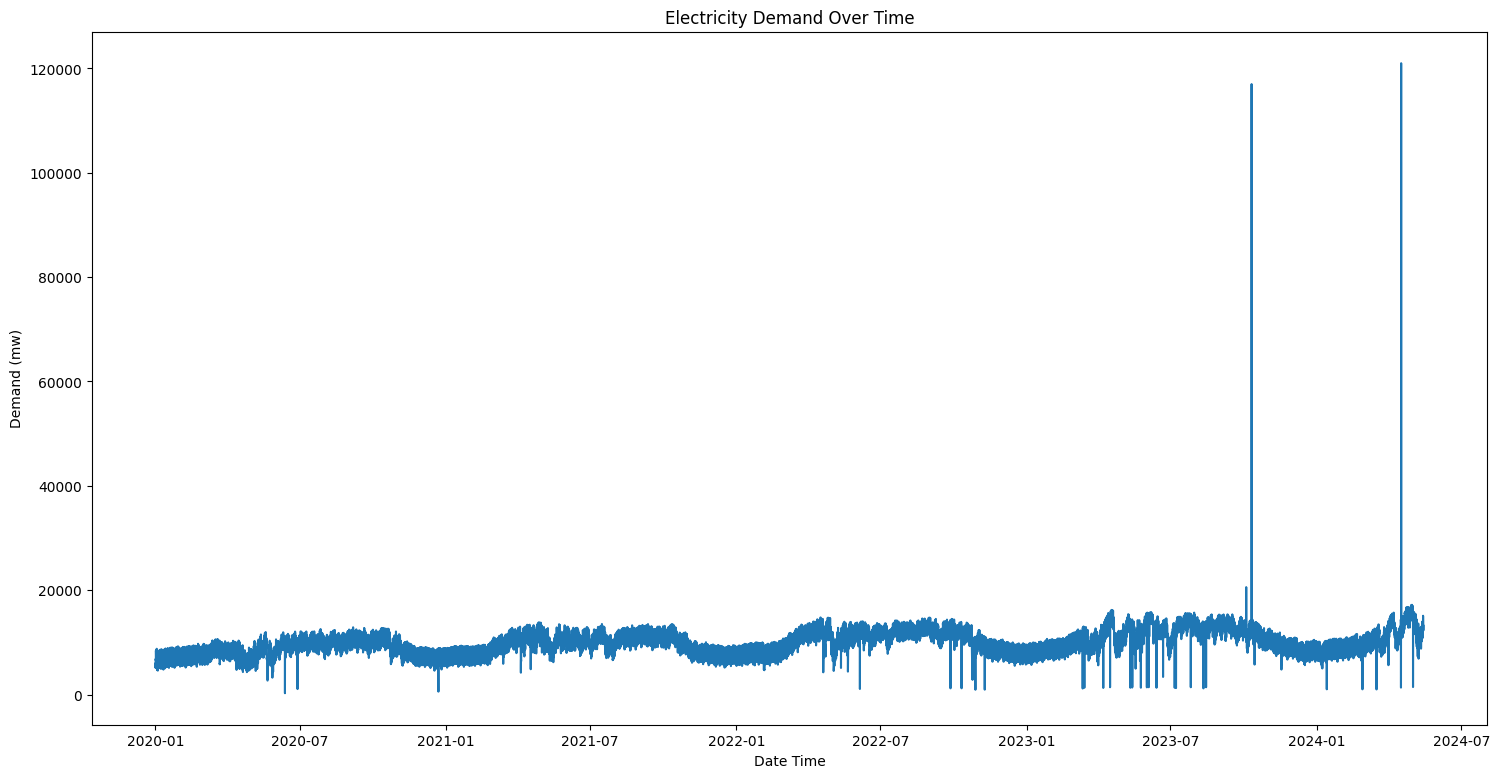

In [286]:
plt.figure(figsize=(18,9))
plt.plot(train_set.index, train_set['demand_mw'])
plt.title("Electricity Demand Over Time")
plt.xlabel("Date Time")
plt.ylabel("Demand (mw)")
plt.show()

### Outlier Detection in `demand_mw`

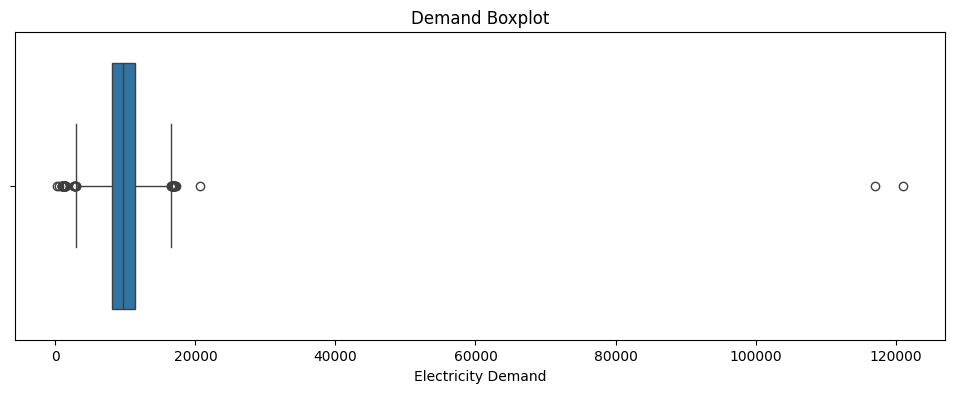

In [287]:
plt.figure(figsize=(12,4))
sns.boxplot(x=train_set['demand_mw'])
plt.title('Demand Boxplot')
plt.xlabel("Electricity Demand")

plt.show()

**Key Observation:** *There is a very large gap between max and normal values, 75% of data is below 11,500 MW,But maximum value is 121,000 MW. This is a clear sign of extreme outliers or data inconsistency .*

### STL Decomposition

In [288]:
from statsmodels.tsa.seasonal import STL

In [289]:
y = train_set['demand_mw']
stl = STL(y, period=24, robust=True)
result = stl.fit()

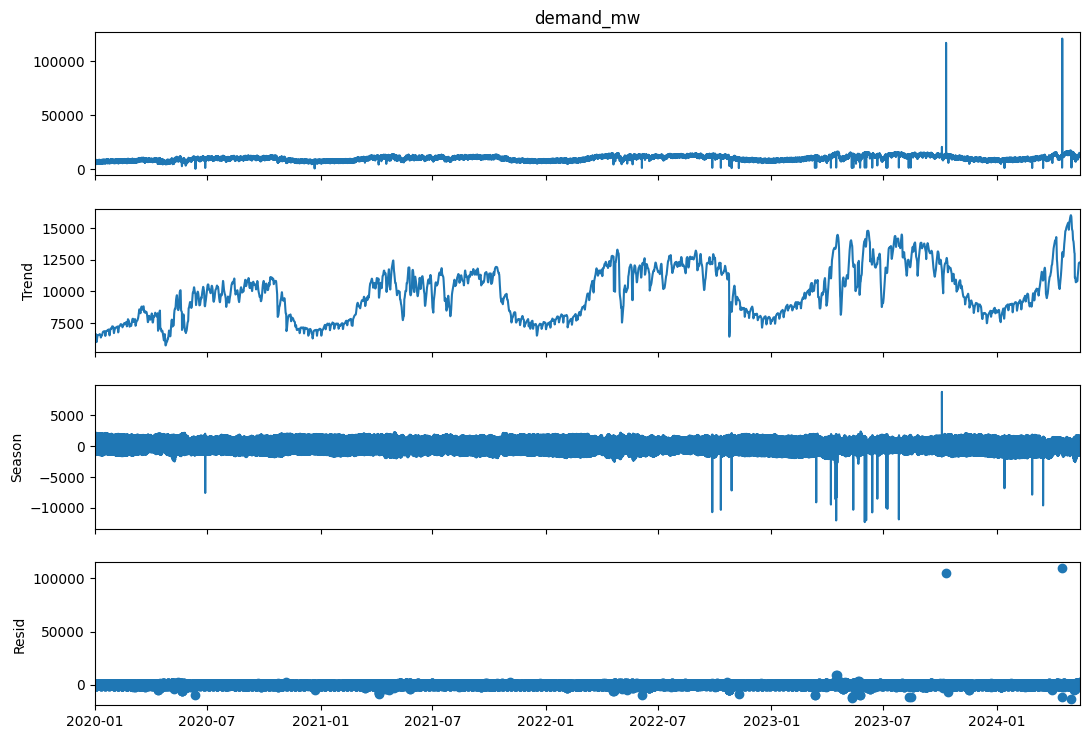

In [290]:
fig = result.plot()
fig.set_size_inches(12, 8)
plt.show()

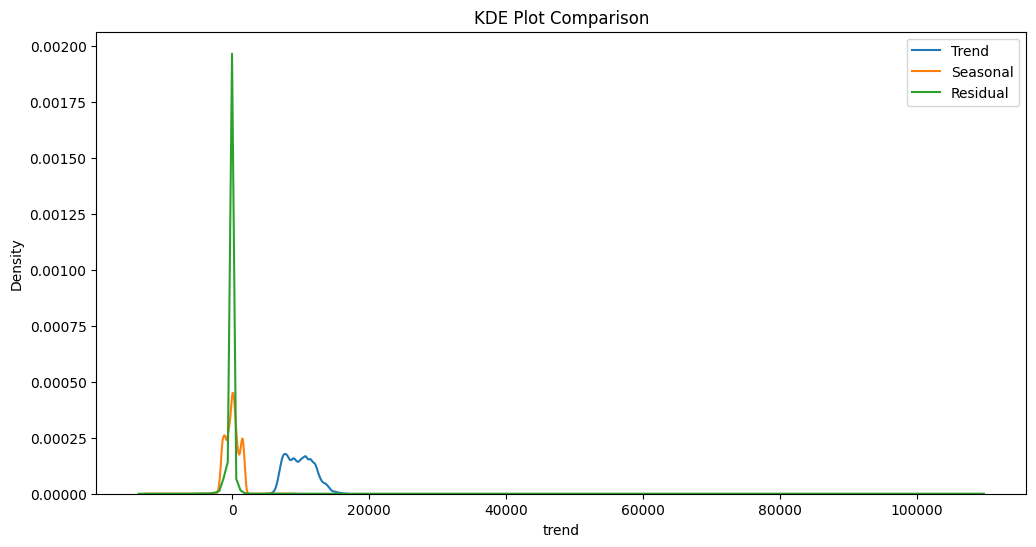

In [291]:
plt.figure(figsize=(12,6))

sns.kdeplot(result.trend, label='Trend')
sns.kdeplot(result.seasonal, label='Seasonal')
sns.kdeplot(result.resid, label='Residual')

plt.legend()
plt.title("KDE Plot Comparison")
plt.show()

### STL (Seasonal-Trend decomposition) summary:

1. Trend (long-term movement):
   - Demand is increasing over years.
   - There are slow cycles (rise → fall → rise).
   - This is not daily noise, it is structural change.
2. Seasonal (repeating pattern):
   - consistent oscillation around zero.
   - STL successfully removed trend and isolated repeating daily pattern.
3. Residual (left):
   - Huge spikes, these are not normal pattern (Outlier problem)
   

In [292]:
# check any negative value in `demand_mw`
(train_set['demand_mw']<0).any()

np.False_

In [293]:
train_set.groupby('weather_condition')['demand_mw'].mean()

weather_condition
cold         7947.506437
heatwave    11403.388122
normal      10098.188969
Name: demand_mw, dtype: float64

In [295]:
# Top 2 rows with highest electricity demand
train_set.nlargest(2, 'demand_mw')

,gen_total_mw,demand_mw,load_shedding_mw,gen_gas_mw,gen_liquid_fuel_mw,gen_coal_mw,gen_hydro_mw,gen_solar_mw,gen_wind_mw,import_india_bheramara_mw,...,temp_c,humidity_pct,rain_mm,wind_speed_ms,hour,remarks,month_name,day_name,weekly_holiday,weather_condition
datetime,,,,,,,,,,,,,,,,,,,,,
2024-04-16 07:00:00,11701.0,121000.0,381.0,6742.0,736.0,2979.0,30.0,190.0,0.0,926.0,...,28.0,73.0,0.0,5.2,7.0,Day_Peak,April,Tuesday,No,normal
2023-10-11 03:00:00,11468.0,117000.0,222.0,6021.0,1225.0,2965.0,200.0,0.0,0.0,913.0,...,25.1,95.0,0.0,6.4,3.0,Night_OffPeak,October,Wednesday,No,normal


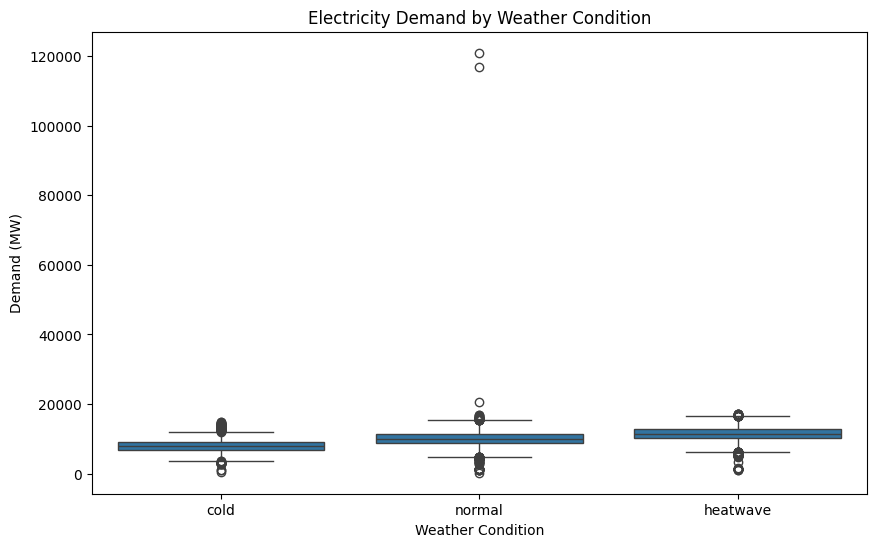

In [296]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=train_set,
    x='weather_condition',
    y='demand_mw'
)

plt.title('Electricity Demand by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Demand (MW)')

plt.show()

In [297]:
# Removes impossible (extreme) anomalies
train_set = train_set[train_set['demand_mw'] < 50000]

In [298]:
# Sort index
train_set = train_set.sort_index()

In [299]:
train_set.shape

(38218, 23)

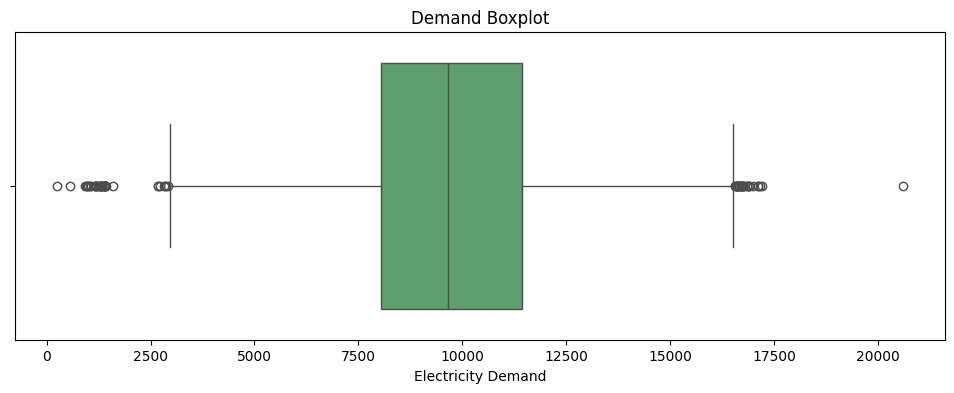

In [300]:
# recheck outlier 
plt.figure(figsize=(12,4))
sns.boxplot(x=train_set['demand_mw'],color='#55A868')
plt.title('Demand Boxplot')
plt.xlabel("Electricity Demand")

plt.show()

## Outlier Handling Approach

Removed only extreme outliers because they are most likely data errors or unrealistic spikes that can mislead the model. However, I kept moderate outliers since they often represent real system behavior such as peak demand, load shedding, or seasonal and weather-driven changes. These patterns are important for forecasting electricity demand accurately, so removing them would cause loss of useful information. Also, I observed that even some extreme values are aligned with normal weather conditions. 

In [301]:
train_set.describe()

,gen_total_mw,demand_mw,load_shedding_mw,gen_gas_mw,gen_liquid_fuel_mw,gen_coal_mw,gen_hydro_mw,gen_solar_mw,gen_wind_mw,import_india_bheramara_mw,import_india_tripura_mw,import_india_adani_mw,import_nepal_mw,temp_c,humidity_pct,rain_mm,wind_speed_ms,hour
count,3.821800e+04,38218.000000,38218.000000,38218.000000,3.821800e+04,38218.000000,38218.000000,38218.000000,38218.000000,38218.000000,38218.000000,38218.0,38218.0,38218.000000,38218.000000,38218.000000,38218.000000,38218.000000
mean,1.132410e+04,9774.917604,140.071158,5427.843922,2.733523e+03,1251.808585,79.765385,49.491018,1.476307,774.334397,113.038987,0.0,0.0,25.333866,76.278351,0.191363,9.259014,11.487388
std,3.300260e+05,2295.310122,397.474484,1102.879358,1.494788e+05,1054.619775,61.465712,93.555101,5.867224,208.130185,33.315704,0.0,0.0,5.363700,16.498702,0.895956,4.825497,6.917727
min,5.710000e+02,254.000000,0.000000,49.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,8.600000,15.000000,0.000000,0.000000,0.000000
25%,8.032000e+03,8041.250000,0.000000,4701.000000,8.502500e+02,550.000000,35.000000,0.000000,0.000000,710.000000,92.000000,0.0,0.0,22.000000,67.000000,0.000000,6.100000,5.000000
50%,9.613000e+03,9663.000000,0.000000,5540.000000,1.779000e+03,730.000000,70.000000,0.000000,0.000000,850.000000,112.000000,0.0,0.0,26.500000,80.000000,0.000000,8.100000,11.000000
75%,1.124800e+04,11443.000000,0.000000,6092.000000,2.889000e+03,1622.750000,118.000000,59.000000,0.000000,924.000000,134.000000,0.0,0.0,29.000000,90.000000,0.000000,11.500000,17.000000
max,6.452650e+07,20587.000000,11672.000000,66662.000000,2.922290e+07,25085.000000,2503.000000,2998.000000,454.000000,9410.000000,1565.000000,0.0,0.0,40.800000,100.000000,39.500000,40.100000,23.000000


In [302]:
test_set.describe()

,gen_total_mw,demand_mw,load_shedding_mw,gen_gas_mw,gen_liquid_fuel_mw,gen_coal_mw,gen_hydro_mw,gen_solar_mw,gen_wind_mw,import_india_bheramara_mw,import_india_tripura_mw,import_india_adani_mw,import_nepal_mw,temp_c,humidity_pct,rain_mm,wind_speed_ms,hour
count,9556.000000,9556.000000,9556.000000,9556.000000,9556.000000,9556.000000,9556.000000,9556.000000,9556.000000,9556.000000,9556.000000,9556.000000,9556.000000,9556.000000,9556.000000,9556.000000,9556.000000,9556.000000
mean,11572.501779,11759.665550,178.660684,5171.868774,1311.416649,3293.436323,104.612547,134.252930,11.440770,851.881802,58.716409,644.567445,0.246547,26.726162,73.864064,0.235894,8.916806,11.503558
std,2078.779920,2475.973527,383.066646,715.763723,1047.162877,943.352538,87.951372,187.346385,19.739775,131.302761,30.355344,501.442163,3.051059,4.643827,18.452078,1.041051,5.389523,6.920834
min,3651.000000,143.000000,0.000000,0.000000,0.000000,829.000000,0.000000,0.000000,0.000000,62.000000,0.000000,0.000000,0.000000,12.400000,15.000000,0.000000,0.000000,0.000000
25%,10091.750000,10095.750000,0.000000,4744.750000,447.750000,2633.000000,40.000000,0.000000,0.000000,877.000000,42.000000,0.000000,0.000000,24.500000,63.000000,0.000000,5.100000,6.000000
50%,11835.000000,11945.000000,30.000000,5139.000000,1118.500000,3288.000000,60.000000,2.000000,5.000000,907.000000,56.000000,751.000000,0.000000,27.100000,78.000000,0.000000,7.800000,12.000000
75%,13122.250000,13500.000000,186.000000,5535.000000,1993.250000,3923.000000,173.000000,257.000000,17.000000,919.000000,72.000000,1016.250000,0.000000,29.700000,89.000000,0.000000,11.700000,17.250000
max,16603.000000,111140.000000,13800.000000,9122.000000,22362.000000,31687.000000,4860.000000,698.000000,922.000000,1011.000000,925.000000,12665.000000,38.000000,40.200000,100.000000,20.900000,55.500000,23.000000


In [303]:
# Need another feature engineering like import electricity, create one features